In [8]:
# Stage 10 Homework — minimal setup

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import probplot  # for QQ plots

from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    r2_score, mean_squared_error, mean_absolute_error,
    confusion_matrix, classification_report
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# redefine RMSE for older sklearn versions
def rmse(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))

print("R²:", round(r2_score(y_test, y_pred), 3))
print("RMSE:", round(rmse(y_test, y_pred), 3))

print("Setup OK (numpy, pandas, matplotlib, sklearn, scipy).")


R²: 0.978
RMSE: 1.804
Setup OK (numpy, pandas, matplotlib, sklearn, scipy).


In [9]:
# Part A: make a clean synthetic regression dataset and save to raw

from pathlib import Path

RAW_DIR = Path(r"C:\Users\User\bootcamp_Khushi_Khanna\homework\homework10\data\raw")
RAW_DIR.mkdir(parents=True, exist_ok=True)

n = 400
X1 = np.random.uniform(0, 10, size=n)                 # main predictor
X2 = np.random.normal(loc=50, scale=10, size=n)       # a second predictor
eps = np.random.normal(0, 2, size=n)                  # noise

# true relationship: y = 3.5*X1 - 0.8*X2 + 120 + noise
y = 3.5 * X1 - 0.8 * X2 + 120 + eps

df_reg = pd.DataFrame({"x1": X1, "x2": X2, "y": y})

# save to raw for traceability (like earlier stages)
out_path = RAW_DIR / "stage10_partA_regression_synth.csv"
df_reg.to_csv(out_path, index=False)

print("Created:", df_reg.shape, "Saved to:", out_path)
df_reg.head()


Created: (400, 3) Saved to: C:\Users\User\bootcamp_Khushi_Khanna\homework\homework10\data\raw\stage10_partA_regression_synth.csv


,x1,x2,y
0,3.745401,63.054788,82.589804
1,9.507143,50.210038,115.313574
2,7.319939,56.819530,100.392619
3,5.986585,46.897332,103.735785
4,1.560186,53.241664,82.140097


In [10]:
# Train/test split and Linear Regression fit

X = df_reg[["x1", "x2"]]
y = df_reg["y"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

linreg = LinearRegression()
linreg.fit(X_train, y_train)

y_pred = linreg.predict(X_test)

print("Coefficients:", linreg.coef_)
print("Intercept:", linreg.intercept_)
print("R²:", round(r2_score(y_test, y_pred), 3))
print("RMSE:", round(rmse(y_test, y_pred), 3))



Coefficients: [ 3.46201809 -0.80000627]
Intercept: 120.4363794861084
R²: 0.978
RMSE: 1.804


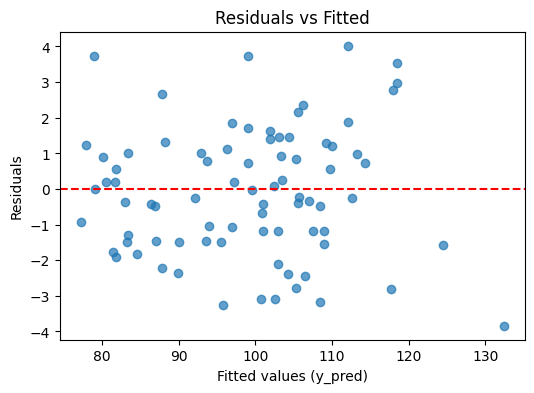

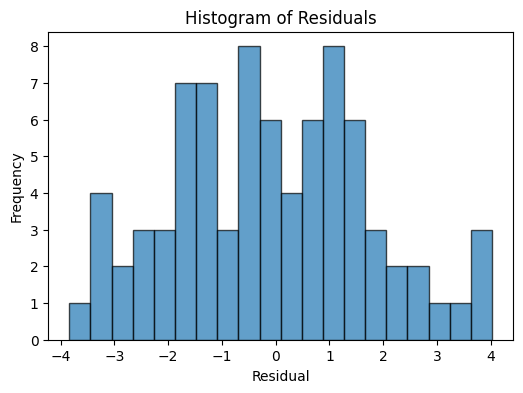

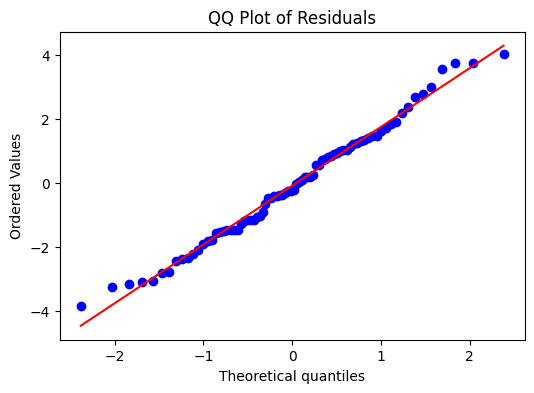

In [11]:
# Residual diagnostics
residuals = y_test - y_pred

# 1. Residuals vs Fitted
plt.figure(figsize=(6,4))
plt.scatter(y_pred, residuals, alpha=0.7)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Fitted values (y_pred)")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted")
plt.show()

# 2. Histogram of residuals
plt.figure(figsize=(6,4))
plt.hist(residuals, bins=20, edgecolor="k", alpha=0.7)
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("Histogram of Residuals")
plt.show()

# 3. QQ Plot (using scipy.stats.probplot)
plt.figure(figsize=(6,4))
probplot(residuals, dist="norm", plot=plt)
plt.title("QQ Plot of Residuals")
plt.show()
